## **Messwerte**

In [1]:
import numpy as np
import sympy as sp
import scipy.optimize
import matplotlib.pyplot as plt
from Skripte.Runden import errRound
from Skripte.Fehlerfortpflanzung import Gaußfehler

T_Fehler_Mess = 0.5

l_fehler_mess = 1e-3

N_schwingungen = 50

phi_0 = np.radians(5) #Anfangsauslenkung in radians

R_masse = 0.03 #Radius der schwingenden Massen (Kugeln) für den Korrekturterm

rho_Luft = 1.204 # kg/m^3 (bei 20°C)

rho_Pendel = 8000 # Dichte des Pendelmaterials in kg/m^3

"""-----------------------------------------------------------------------------------------------------------------------------------"""

l_abstaende_1 = np.array([0.90, 0.95, 1.00, 1.05, 1.10, 1.15]) # Schneidenabstände in Meter


t_50_1_M = np.array([ 98.1 , 99.5 , 101.0 , 102.5 , 104.1 , 105.8])  # Zeiten für 50 Schwingungen (Aufhängung 1) in s

T_1 = t_50_1_M / N_schwingungen
T_1_Fehler = T_Fehler_Mess / 50
T1_sq = T_1**2
T1_sq_Fehler = 2 * T_1 * T_1_Fehler  # Fehlerfortpflanzung für T^2

"""-----------------------------------------------------------------------------------------------------------------------------------"""


l_abstaende_2 = np.array([0.90, 0.95, 1.00, 1.05, 1.10, 1.15]) # Schneidenabstände in Meter


t_50_2_M = np.array([105.2 , 103.8 , 102.1 , 100.8 , 99.2 , 97.5])  # Zeiten für 50 Schwingungen (Aufhängung 2)

T_2 = t_50_2_M / N_schwingungen
T_2_Fehler = T_Fehler_Mess / 50
T2_sq = T_2**2
T2_sq_Fehler = 2 * T_2 * T_2_Fehler  # Fehlerfortpflanzung für T^2



## **Plots und lineare Regression**

Gerade 1: m = 2.5015 +/- 0.1948, c = 1.5867 +/- 0.1995
Gerade 2: m = -2.4852 +/- 0.1938, c = 6.6656 +/- 0.2002


(-c1 + c2)/(m1 - m2)


Schnittpunkt (Reduzierte Pendellänge): l_S = 1.02 +/- 0.08 m
Quadrierte Periodendauer am Schnittpunkt: T_S^2 = 4.13 +/- 0.2 s^2


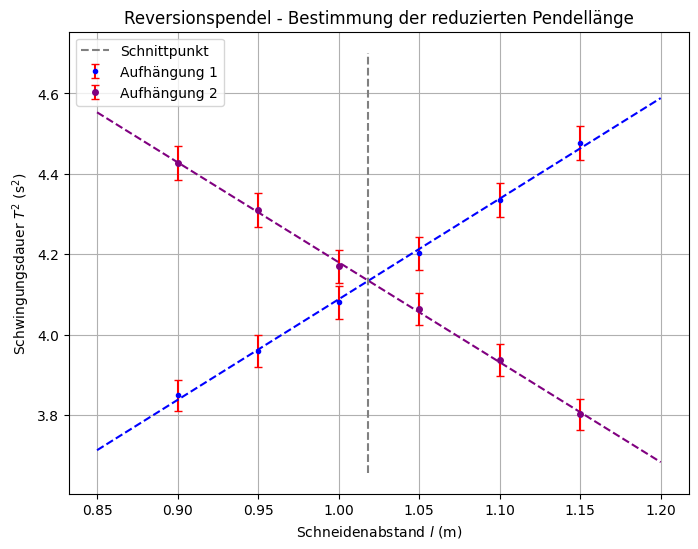

In [2]:


def linear_fit(x, m, c):
    return m * x + c

# Fit für Aufhängung 1
popt1, pcov1 = scipy.optimize.curve_fit(linear_fit, l_abstaende_1, T1_sq, sigma=T1_sq_Fehler, absolute_sigma=True)
m1, c1 = popt1
m1_err, c1_err = np.sqrt(np.diag(pcov1))

# Fit für Aufhängung 2
popt2, pcov2 = scipy.optimize.curve_fit(linear_fit, l_abstaende_2, T2_sq, sigma=T2_sq_Fehler, absolute_sigma=True)
m2, c2 = popt2
m2_err, c2_err = np.sqrt(np.diag(pcov2))

print(f"Gerade 1: m = {m1:.4f} +/- {m1_err:.4f}, c = {c1:.4f} +/- {c1_err:.4f}")
print(f"Gerade 2: m = {m2:.4f} +/- {m2_err:.4f}, c = {c2:.4f} +/- {c2_err:.4f}")


"----------------------------------------------------------------------------------------------------------------------------------"


#Berechnung des Schnittpunkts


# SymPy Definitionen für die Gauß'sche Fehlerfortpflanzung des Schnittpunkts
sm1, sc1, sm2, sc2 = sp.symbols("m1 c1 m2 c2")
expr_l_S = (sc2 - sc1) / (sm1 - sm2)
display(expr_l_S)

Variablen_S = np.array([sm1, sc1, sm2, sc2])
Werte_S = np.array([m1, c1, m2, c2])
Fehler_S = np.array([m1_err, c1_err, m2_err, c2_err])

# Schnittpunkt l_S (x-Koordinate)
l_S = (c2 - c1) / (m1 - m2)
l_S_Fehler = Gaußfehler(expr_l_S, Variablen_S, Werte_S, Fehler_S)

ls_round = errRound(l_S, l_S_Fehler)
print(f"\nSchnittpunkt (Reduzierte Pendellänge): l_S = {ls_round[0]} +/- {ls_round[1]} m")

# Schnittpunkt T_S^2 (y-Koordinate, eingesetzt in Gerade 1)
expr_T_S_sq = sm1 * expr_l_S + sc1
T_S_sq = m1 * l_S + c1
T_S_sq_Fehler = Gaußfehler(expr_T_S_sq, Variablen_S, Werte_S, Fehler_S)

ts2_round = errRound(T_S_sq, T_S_sq_Fehler)
print(f"Quadrierte Periodendauer am Schnittpunkt: T_S^2 = {ts2_round[0]} +/- {ts2_round[1]} s^2")


"""----------------------------------------------------------------------------------------------------------------------------------"""

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

ax1.errorbar(l_abstaende_1, T1_sq, yerr=T1_sq_Fehler, fmt="o", label="Aufhängung 1", color="blue", markersize=3, capsize=3, ecolor="r")
ax1.errorbar(l_abstaende_2, T2_sq, yerr=T2_sq_Fehler, fmt="o", label="Aufhängung 2", color="purple", markersize=4, capsize=3, ecolor="r")

x_plot = np.linspace(min(l_abstaende_1)-0.05, max(l_abstaende_1)+0.05, 100)
ax1.plot(x_plot, m1 * x_plot + c1, color="blue", linestyle="--")
ax1.plot(x_plot, m2 * x_plot + c2, color="purple", linestyle="--")

ax1.vlines(l_S, ymin = np.min(T1_sq)*0.95, ymax = np.max(T1_sq)*1.05, linestyle ="--", color = "grey", label = "Schnittpunkt")


ax1.set_xlabel(r"Schneidenabstand $l$ (m)")
ax1.set_ylabel(r"Schwingungsdauer $T^2$ (s$^2$)")
ax1.grid(True)
ax1.set_title("Reversionspendel - Bestimmung der reduzierten Pendellänge")
ax1.legend()
plt.show()

## **Berechnung von g und Korrekturterme**

In [3]:

sl, sT2 = sp.symbols("l T_sq")
expr_g = 4 * sp.pi**2 * sl / sT2
display(expr_g)

g_calc = 4 * np.pi**2 * l_S / T_S_sq
g_calc_Fehler = Gaußfehler(expr_g, np.array([sl, sT2]), np.array([l_S, T_S_sq]), np.array([l_S_Fehler, T_S_sq_Fehler]))


rel_fehler_g = (g_calc_Fehler / g_calc) * 100

print(f"\nLokale Erdbeschleunigung: g = {g_calc} +/- {g_calc_Fehler} m/s^2")
print(f"Relativer Fehler von g: {rel_fehler_g:.2f} %")

"""-----------------------------------------------------------------------------------------------"""
print("\n--- Korrekturterme ---")

# a) Winkelnäherung
T_korr_faktor = (1 + (1/16) * phi_0**2)
g_korr_winkel = g_calc / T_korr_faktor**2  # g proportional 1/T^2
print(f"a) Einfluss der Winkelnäherung: g verschiebt sich auf {g_korr_winkel:} m/s^2")

# b) Näherung mathematisches Pendel - physikalisches Pendel (Beispielwerte)

l_korr_faktor = (1 + (2/5) * (R_masse**2 / l_S**2))
g_korr_phys = g_calc * l_korr_faktor
print(f"b) Einfluss der Massenausdehnung: g verschiebt sich auf {g_korr_phys:} m/s^2")

# c) Auftriebskorrektur in Luft
m_korr_faktor = (1 - (rho_Luft / rho_Pendel))
g_korr_auftrieb = g_calc / m_korr_faktor
print(f"c) Auftrieb in der Luft: g verschiebt sich auf {g_korr_auftrieb} m/s^2")

4*pi**2*l/T_sq


Lokale Erdbeschleunigung: g = 9.72511956550251 +/- 0.8938363383702431 m/s^2
Relativer Fehler von g: 9.19 %

--- Korrekturterme ---
a) Einfluss der Winkelnäherung: g verschiebt sich auf 9.715868543175551 m/s^2
b) Einfluss der Massenausdehnung: g verschiebt sich auf 9.728494735083537 m/s^2
c) Auftrieb in der Luft: g verschiebt sich auf 9.726583416306665 m/s^2
